In [ ]:
import re
import pandas as pd

In [ ]:
file_path = "WhatsApp Chat with 2025-26 TE CMPN ALL.txt"

with open(file_path, encoding="utf-8") as file:
    data = file.read()

print("Chat file loaded successfully!")


Chat file loaded successfully!


In [ ]:
pattern = r"\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s[APap][Mm]\s-"


In [ ]:
messages = re.split(pattern, data)[1:]
dates = re.findall(pattern, data)

print(f"Total messages: {len(messages)}")
print(f"Total dates: {len(dates)}")


Total messages: 1773
Total dates: 1773


In [ ]:
df = pd.DataFrame({
    "message_date": dates,
    "message": messages
})

df.head()


,message_date,message
0,"01/07/24, 2:16 pm -",Messages and calls are end-to-end encrypted. ...
1,"01/07/24, 1:14 pm -","~ gaikwadkunal5090 created group ""CMPN SE ABC""\n"
2,"01/07/24, 2:16 pm -",You joined using this group's invite link\n
3,"01/07/24, 2:17 pm -",+91 87676 54601 was added\n
4,"01/07/24, 2:16 pm -",+91 87676 54601 joined using a group link.\n


In [ ]:

df["message_date"] = df["message_date"].str.replace("\u202f", " ", regex=False)

df["message_date"] = pd.to_datetime(
    df["message_date"],
    format="%d/%m/%y, %I:%M %p -"
)

df.head()



,message_date,message
0,2024-07-01 14:16:00,Messages and calls are end-to-end encrypted. ...
1,2024-07-01 13:14:00,"~ gaikwadkunal5090 created group ""CMPN SE ABC""\n"
2,2024-07-01 14:16:00,You joined using this group's invite link\n
3,2024-07-01 14:17:00,+91 87676 54601 was added\n
4,2024-07-01 14:16:00,+91 87676 54601 joined using a group link.\n


In [ ]:
users = []
texts = []

for message in df["message"]:
    entry = re.split(r"([\w\W]+?):\s", message)
    if entry[1:]:
        users.append(entry[1])
        texts.append(entry[2])
    else:
        users.append("group_notification")
        texts.append(entry[0])

df["user"] = users
df["text"] = texts

df.head()


,message_date,message,user,text
0,2024-07-01 14:16:00,Messages and calls are end-to-end encrypted. ...,group_notification,Messages and calls are end-to-end encrypted. ...
1,2024-07-01 13:14:00,"~ gaikwadkunal5090 created group ""CMPN SE ABC""\n",group_notification,"~ gaikwadkunal5090 created group ""CMPN SE ABC""\n"
2,2024-07-01 14:16:00,You joined using this group's invite link\n,group_notification,You joined using this group's invite link\n
3,2024-07-01 14:17:00,+91 87676 54601 was added\n,group_notification,+91 87676 54601 was added\n
4,2024-07-01 14:16:00,+91 87676 54601 joined using a group link.\n,group_notification,+91 87676 54601 joined using a group link.\n


In [ ]:
df.drop(columns=["message"], inplace=True)
df.head()

,message_date,user,text
0,2024-07-01 14:16:00,group_notification,Messages and calls are end-to-end encrypted. ...
1,2024-07-01 13:14:00,group_notification,"~ gaikwadkunal5090 created group ""CMPN SE ABC""\n"
2,2024-07-01 14:16:00,group_notification,You joined using this group's invite link\n
3,2024-07-01 14:17:00,group_notification,+91 87676 54601 was added\n
4,2024-07-01 14:16:00,group_notification,+91 87676 54601 joined using a group link.\n


In [ ]:
df["year"] = df["message_date"].dt.year
df["month"] = df["message_date"].dt.month_name()
df["day"] = df["message_date"].dt.day
df["hour"] = df["message_date"].dt.hour
df["minute"] = df["message_date"].dt.minute

In [ ]:
df.head()

,message_date,user,text,year,month,day,hour,minute
0,2024-07-01 14:16:00,group_notification,Messages and calls are end-to-end encrypted. ...,2024,July,1,14,16
1,2024-07-01 13:14:00,group_notification,"~ gaikwadkunal5090 created group ""CMPN SE ABC""\n",2024,July,1,13,14
2,2024-07-01 14:16:00,group_notification,You joined using this group's invite link\n,2024,July,1,14,16
3,2024-07-01 14:17:00,group_notification,+91 87676 54601 was added\n,2024,July,1,14,17
4,2024-07-01 14:16:00,group_notification,+91 87676 54601 joined using a group link.\n,2024,July,1,14,16


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1773 entries, 0 to 1772
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   message_date  1773 non-null   datetime64[ns]
 1   user          1773 non-null   object        
 2   text          1773 non-null   object        
 3   year          1773 non-null   int32         
 4   month         1773 non-null   object        
 5   day           1773 non-null   int32         
 6   hour          1773 non-null   int32         
 7   minute        1773 non-null   int32         
dtypes: datetime64[ns](1), int32(4), object(3)
memory usage: 83.2+ KB


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


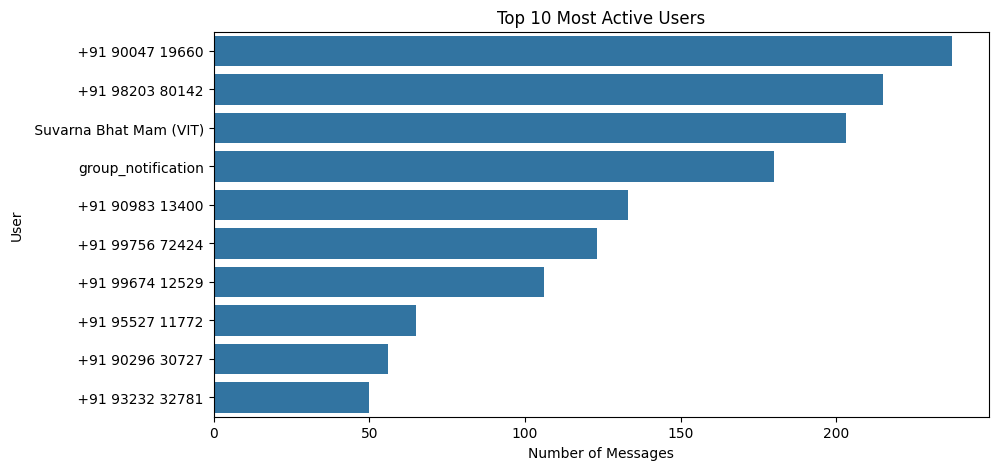

In [ ]:
user_counts = df["user"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=user_counts.values, y=user_counts.index)
plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Messages")
plt.ylabel("User")
plt.show()


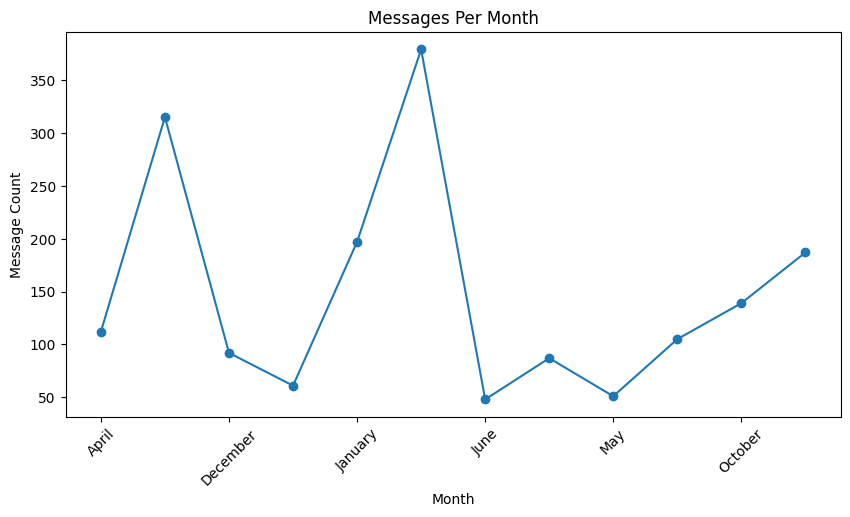

In [ ]:
monthly_messages = df.groupby("month").size()

plt.figure(figsize=(10, 5))
monthly_messages.plot(kind="line", marker="o")
plt.title("Messages Per Month")
plt.xlabel("Month")
plt.ylabel("Message Count")
plt.xticks(rotation=45)
plt.show()


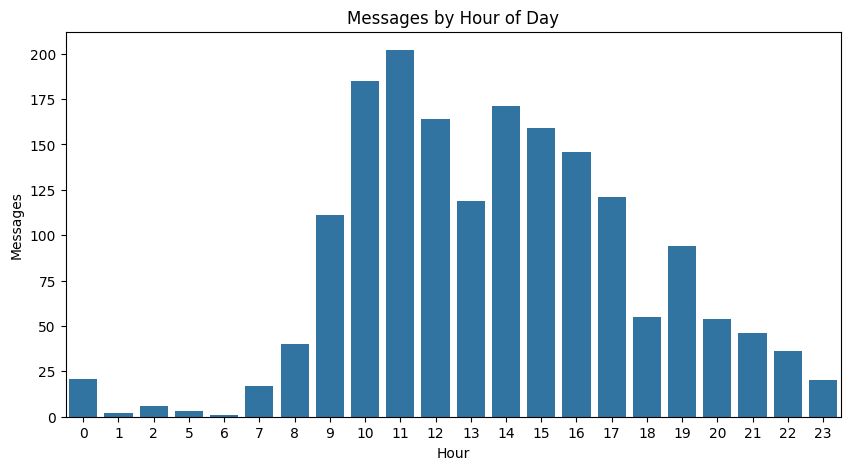

In [ ]:
hourly_messages = df.groupby("hour").size()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_messages.index, y=hourly_messages.values)
plt.title("Messages by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Messages")
plt.show()


In [ ]:
df["user"].unique()


array(['group_notification', ' Suvarna Bhat Mam (VIT)', ' Chavan VIT',
       ' +91 89284 23088', ' Sahil Mahadik VIT', ' +91 96075 57799',
       ' +91 98695 02400', ' +91 89033 86784', ' +91 81089 75740',
       ' +91 99879 32618', ' +91 98673 18377', ' +91 72081 55789',
       ' +91 77095 14267', ' +91 93240 01786', ' +91 90224 46161',
       ' Mrugendra VIT', ' +91 98332 84729', ' +91 91673 73151',
       ' +91 88282 72687', ' +91 74999 02852', ' +91 81046 61197',
       ' +91 95292 12021', ' +91 95949 79697', ' +91 97690 62368',
       ' +91 93248 73439', ' Atharva VIT', ' +91 93729 93831',
       ' +91 95185 63596', ' +91 91365 40564', ' +91 93214 08001',
       ' +91 70211 89136', ' Prithvi VIT', ' +91 91370 93339',
       ' +91 93232 32781', ' +91 87791 87006', ' +91 98203 80142',
       ' +91 99756 72424', ' +91 99674 12529', ' +91 98702 69896',
       ' +91 80826 01058', ' Sanjeev Sir VIT', ' +91 90983 13400',
       ' +91 98192 83485', ' +91 98202 32628', ' +91 98201 25351',

In [ ]:
selected_user = " Suvarna Bhat Mam (VIT)"  # change this

user_df = df[df["user"] == selected_user]

print(f"Total messages by {selected_user}: {user_df.shape[0]}")


Total messages by  Suvarna Bhat Mam (VIT): 203


['group_notification' ' Suvarna Bhat Mam (VIT)' ' Chavan VIT'
 ' +91 89284 23088' ' Sahil Mahadik VIT' ' +91 96075 57799'
 ' +91 98695 02400' ' +91 89033 86784' ' +91 81089 75740'
 ' +91 99879 32618' ' +91 98673 18377' ' +91 72081 55789'
 ' +91 77095 14267' ' +91 93240 01786' ' +91 90224 46161' ' Mrugendra VIT'
 ' +91 98332 84729' ' +91 91673 73151' ' +91 88282 72687'
 ' +91 74999 02852' ' +91 81046 61197' ' +91 95292 12021'
 ' +91 95949 79697' ' +91 97690 62368' ' +91 93248 73439' ' Atharva VIT'
 ' +91 93729 93831' ' +91 95185 63596' ' +91 91365 40564'
 ' +91 93214 08001' ' +91 70211 89136' ' Prithvi VIT' ' +91 91370 93339'
 ' +91 93232 32781' ' +91 87791 87006' ' +91 98203 80142'
 ' +91 99756 72424' ' +91 99674 12529' ' +91 98702 69896'
 ' +91 80826 01058' ' Sanjeev Sir VIT' ' +91 90983 13400'
 ' +91 98192 83485' ' +91 98202 32628' ' +91 98201 25351'
 ' +91 90047 19660' ' Uday Sir VIT' ' +91 89832 36225' ' +91 98209 60295'
 ' +91 97733 21569' ' +91 95527 11772' ' +91 99204 83789'
 ' 

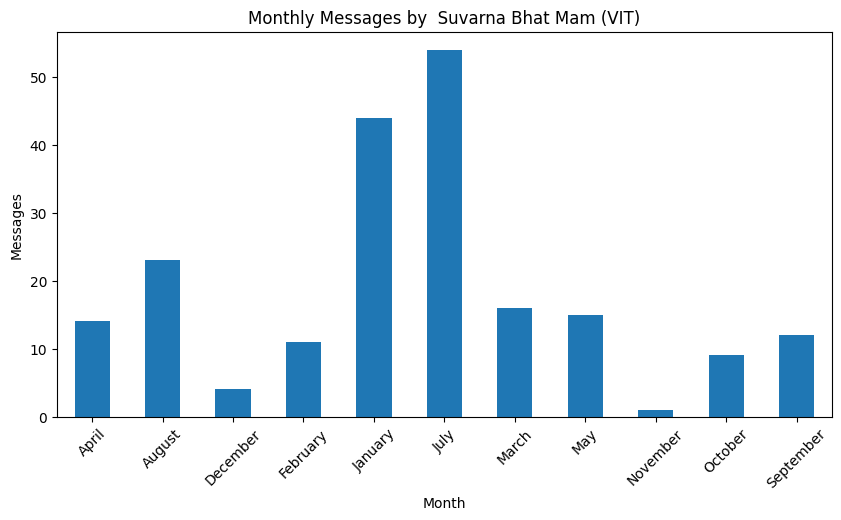

In [ ]:
print(df["user"].unique())

selected_user = " Suvarna Bhat Mam (VIT)"

user_df = df[df["user"].str.strip() == selected_user.strip()]

if user_df.empty:
    print(f"No messages found for user: {selected_user}")
else:
    user_monthly = user_df.groupby("month").size()

    plt.figure(figsize=(10, 5))
    user_monthly.plot(kind="bar")
    plt.title(f"Monthly Messages by {selected_user}")
    plt.xlabel("Month")
    plt.ylabel("Messages")
    plt.xticks(rotation=45)
    plt.show()



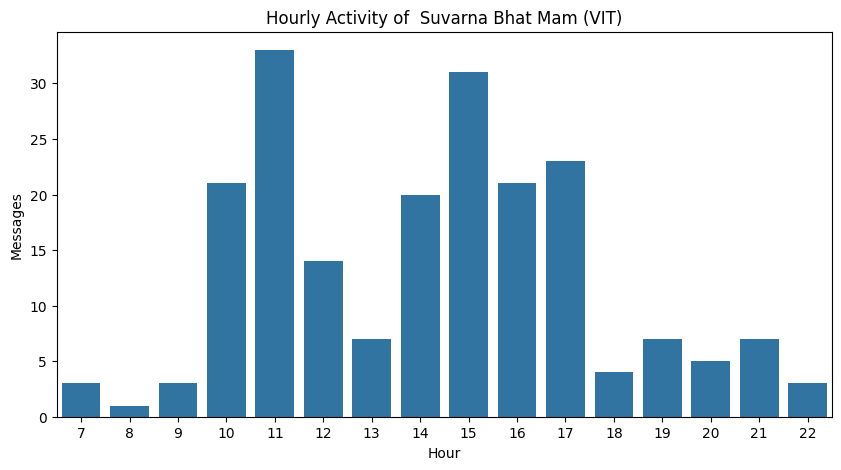

In [ ]:
user_hourly = user_df.groupby("hour").size()

plt.figure(figsize=(10, 5))
sns.barplot(x=user_hourly.index, y=user_hourly.values)
plt.title(f"Hourly Activity of {selected_user}")
plt.xlabel("Hour")
plt.ylabel("Messages")
plt.show()


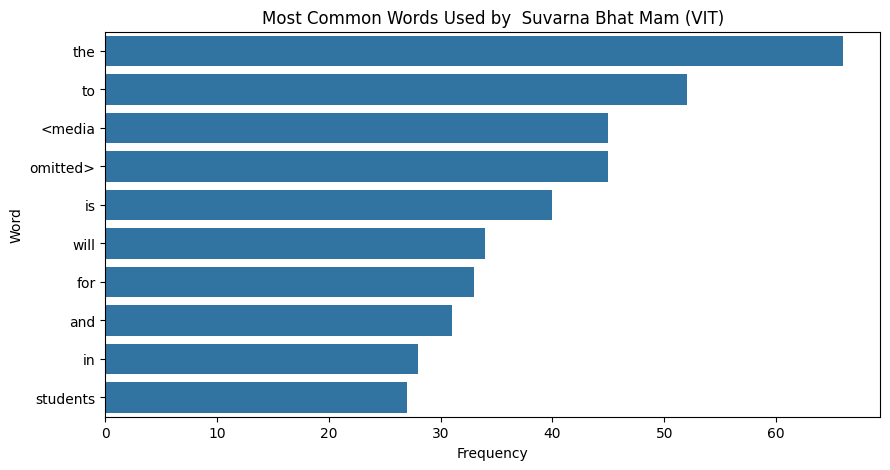

In [ ]:
from collections import Counter

words = " ".join(user_df["text"]).lower().split()
common_words = Counter(words).most_common(10)

word_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

plt.figure(figsize=(10, 5))
sns.barplot(x="Frequency", y="Word", data=word_df)
plt.title(f"Most Common Words Used by {selected_user}")
plt.show()


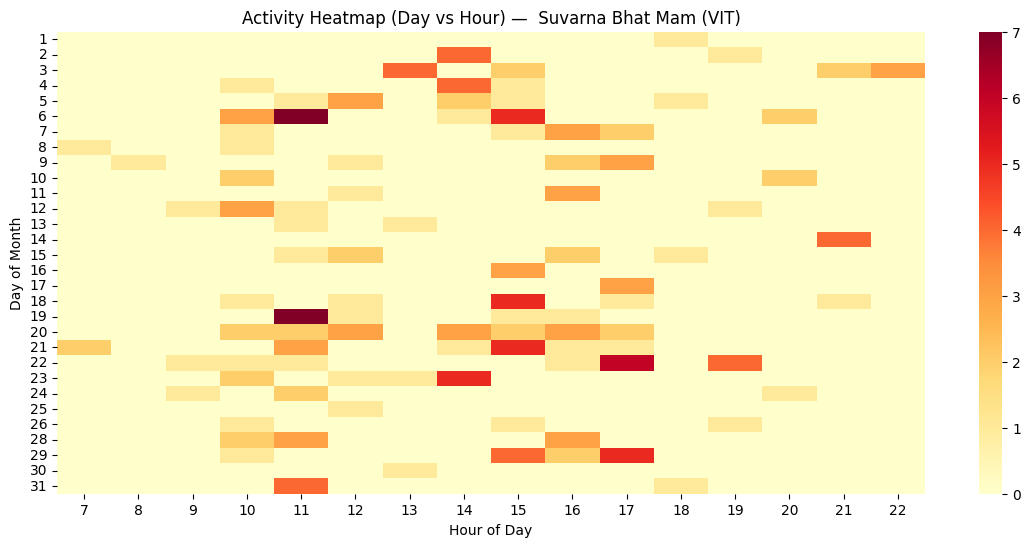

In [ ]:
user_df = df[df["user"].str.strip() == selected_user.strip()]

if user_df.empty:
    print("No data for selected user")
else:
    heatmap_data = user_df.groupby(["day", "hour"]).size().unstack(fill_value=0)

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap="YlOrRd")
    plt.title(f"Activity Heatmap (Day vs Hour) — {selected_user}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Day of Month")
    plt.show()


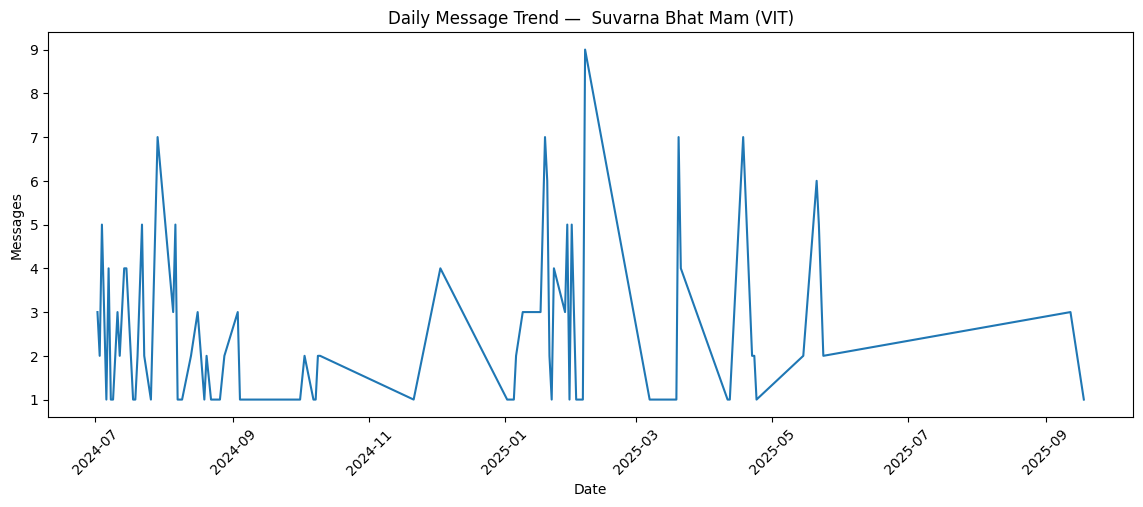

In [ ]:
user_df = df[df["user"].str.strip() == selected_user.strip()]

if user_df.empty:
    print("No data for selected user")
else:
    daily_msgs = user_df.groupby(user_df["message_date"].dt.date).size()

    plt.figure(figsize=(14, 5))
    plt.plot(daily_msgs.index, daily_msgs.values)
    plt.title(f"Daily Message Trend — {selected_user}")
    plt.xlabel("Date")
    plt.ylabel("Messages")
    plt.xticks(rotation=45)
    plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127882 (\N{CONFETTI BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


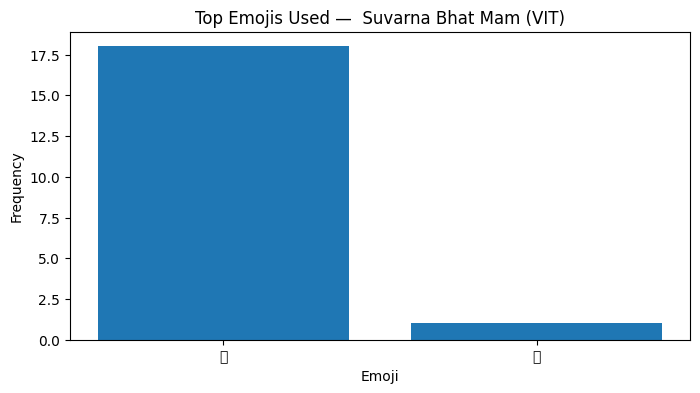

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import re

def extract_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.findall(text)

user_df = df[df["user"].str.strip() == selected_user.strip()]

if user_df.empty:
    print("No data for selected user")
else:
    emojis = []
    for msg in user_df["text"]:
        emojis.extend(extract_emojis(msg))

    emoji_freq = Counter(emojis).most_common(10)

    if len(emoji_freq) == 0:
        print("No emojis used by this user.")
    else:
        emoji_df = pd.DataFrame(emoji_freq, columns=["Emoji", "Count"])

        plt.figure(figsize=(8, 4))
        plt.bar(emoji_df["Emoji"], emoji_df["Count"])
        plt.title(f"Top Emojis Used — {selected_user}")
        plt.xlabel("Emoji")
        plt.ylabel("Frequency")
        plt.show()
